<a href="https://colab.research.google.com/github/MicaelaDelgadom/CursoDataScience/blob/main/ProyectoFinal_MicaelaDelgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#**Impacto de los hábitos digitales y el bienestar personal en la productividad laboral**

---



#Introducción

Este proyecto analiza cómo los hábitos digitales, como el uso de redes sociales, las notificaciones y el tiempo de pantalla, impactan en la productividad, el estrés, el sueño y la satisfacción laboral de los trabajadores.


A partir de un dataset con 30.000 registros, exploramos patrones entre variables como:
- Horas en redes sociales
- Productividad real vs percibida
- Niveles de estrés y horas de sueño
- Uso de apps de enfoque y bienestar digital

---

##Objetivo General

El presente proyecto tiene como finalidad **desarrollar un modelo predictivo de regresión** capaz de estimar la **productividad real (`actual_productivity_score`)** de las personas, utilizando como base un conjunto de variables relacionadas con los **hábitos digitales, el bienestar personal y las características demográficas**.

El enfoque se centra en analizar cómo la tecnología —a través del uso de redes sociales, las notificaciones constantes y el tiempo frente a pantallas— puede influir positiva o negativamente en el rendimiento laboral.  
Asimismo, se consideran factores de bienestar como el sueño, el estrés y la satisfacción laboral, que inciden directamente en la capacidad de concentración y en la eficiencia diaria.

A través del modelo predictivo, se busca **identificar patrones y relaciones** entre estas variables, con el fin de comprender qué factores tienen mayor impacto en la productividad y cómo pueden aprovecharse para **mejorar el bienestar y el rendimiento** de las personas en entornos profesionales.

---

##Contexto Aplicado

Vivimos en una era hiperconectada donde la línea entre la vida laboral y digital es cada vez más difusa.  
El uso excesivo de redes sociales, la sobrecarga de información y la falta de desconexión digital generan efectos directos sobre la atención, la motivación y la productividad.

Este proyecto se enmarca dentro de un contexto social y laboral en el que:
- Las **notificaciones constantes** pueden convertirse en distractores que fragmentan la concentración.  
- La **falta de descanso** y las **malas rutinas de sueño** reducen el rendimiento cognitivo.  
- La **percepción de productividad** muchas veces no coincide con la productividad real, lo que genera frustración o sensación de ineficiencia.  

Comprender estas relaciones mediante herramientas de análisis y modelado predictivo puede ofrecer una base sólida para **diseñar estrategias de bienestar digital**, fomentar la **eficiencia laboral sostenible** y apoyar la toma de decisiones tanto personales como organizacionales.

---
##Problema de Negocio / Justificación

En los últimos años, el interés por la productividad personal ha crecido de forma exponencial, impulsado por el avance tecnológico y los cambios en los modelos de trabajo (presencial, remoto e híbrido).  
Sin embargo, aún existen muchas incógnitas sobre **qué factores concretos determinan el rendimiento real** de una persona.

Este estudio busca responder a preguntas como:
- ¿Qué hábitos digitales afectan más a la productividad real?  
- ¿Hasta qué punto el estrés o el sueño influyen en el rendimiento diario?  
- ¿Es posible predecir el nivel de productividad de una persona a partir de sus datos digitales y de bienestar?  

La construcción de este modelo predictivo permitirá **cuantificar y explicar** esas relaciones, brindando información útil tanto para empleados como para empleadores.  
En un futuro, este tipo de modelos podrían servir como base para el desarrollo de **aplicaciones de bienestar digital** o **sistemas de monitoreo de productividad saludable**, siempre respetando la privacidad y el uso ético de los datos.

---

##Alcance del Proyecto

El proyecto se limita al análisis del dataset proporcionado (30.000 registros), el cual contiene variables demográficas, digitales, de bienestar y de productividad.  
No se incluyen variables psicológicas o de contexto externo (como tipo de empresa o nivel educativo), por lo que las conclusiones estarán enfocadas en las relaciones **entre hábitos digitales, bienestar personal y productividad laboral**.

El resultado final será un **modelo de regresión** validado con métricas básicas (R², MAE y RMSE), acompañado de una interpretación de los factores más influyentes en la productividad real.



##Preguntas e hipótesis

**Hábitos digitales y productividad real:**

Se espera que un mayor tiempo diario en redes sociales o una mayor cantidad de notificaciones se asocie con una menor productividad real. El exceso de estímulos digitales podría afectar la concentración y dificultar la gestión del tiempo.

**Estrés, sueño y rendimiento diario:**

Se plantea que las personas con niveles elevados de estrés tienden a presentar menor productividad percibida y menor satisfacción laboral. Por el contrario, quienes duermen más horas muestran una mayor productividad real, dado que el descanso adecuado favorece la atención y el desempeño cognitivo.

**Factores predictivos de productividad:**

Se considera que tanto las variables de bienestar (estrés, sueño, burnout, consumo de café) como los hábitos digitales (uso de apps de enfoque, tiempo en redes, notificaciones) pueden servir como predictores significativos de la productividad real. Comprender su interacción permitirá construir modelos capaces de estimar el rendimiento de manera más precisa.

#1. Carga de datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [18]:
url = "https://raw.githubusercontent.com/MicaelaDelgadom/CursoDataScience/refs/heads/Data-I/social_media_vs_productivity.csv"
df = pd.read_csv(url)

print("El archivo ha sido cargado correctamente")

El archivo ha sido cargado correctamente


# 2. Exploración inicial

In [19]:
df.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [21]:
df.columns

Index(['age', 'gender', 'job_type', 'daily_social_media_time',
       'social_platform_preference', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score'],
      dtype='object')

Presentación del dataset

El dataset contiene 30.000 registros y 19 columnas que cubren distintas dimensiones de la vida digital y laboral de los individuos. Las variables se pueden agrupar en las siguientes categorías:

Datos demográficos
- Edad (`age`)
- Género (`gender`)
- Tipo de trabajo (`job_type`)

Uso digital y tecnología
- Tiempo diario en redes sociales (`daily_social_media_time`)
- Plataforma de redes preferida (`social_platform_preference`)
- Número de notificaciones diarias (`number_of_notifications`)
- Tiempo frente a pantalla antes de dormir (`screen_time_before_sleep`)
- Uso de apps de enfoque (`uses_focus_apps`)
- Uso de herramientas de bienestar digital (`has_digital_wellbeing_enabled`)
- Horas offline por semana (`weekly_offline_hours`)

Productividad y rendimiento
- Productividad percibida (`perceived_productivity_score`)
- Productividad real (`actual_productivity_score`)
- Horas de trabajo por día (`work_hours_per_day`)
- Número de descansos durante el trabajo (`breaks_during_work`)

Bienestar y salud
- Nivel de estrés (`stress_level`)
- Horas de sueño (`sleep_hours`)
- Consumo diario de café (`coffee_consumption_per_day`)
- Días con burnout al mes (`days_feeling_burnout_per_month`)
- Satisfacción laboral (`job_satisfaction_score`)




# 3. Manipulación y limpieza de datos

##Comprobación de datos NaN

In [22]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64


Al ejecutar `df.isnull().sum()`, observamos que varias columnas presentan valores nulos, especialmente:

- `daily_social_media_time`: 2765 valores nulos
- `perceived_productivity_score 1614`: 1614 valores nulos
- `actual_productivity_score`: 2365 valores nulos
- `sleep_hours`: 2598 valores nulos
- `job_satisfaction_score`: 2730 valores nulos
- `screen_time_before_sleep`: 2211 valores nulos
- `stress_level`: 1904 valores nulos

Consideraciones sobre valores nulos en personas desempleadas

Para rellenar los valores nulos en el dataset, se ha optado por utilizar la **mediana** en las columnas numéricas. Esta decisión se basa en que la mediana no se ve afectada por valores atípicos (outliers) y permite mantener la coherencia del conjunto de datos sin eliminar filas completas.

Sin embargo, hay excepciones importantes a tener en cuenta:

- La variable `job_satisfaction_score` solo tiene sentido para personas con empleo. Por lo tanto, si este campo está vacío en individuos cuyo `job_type` es "Unemployed", se interpreta como un dato no aplicable, y **no se rellenará**.

Estas decisiones buscan preservar la lógica del contexto original de los datos y evitar introducir información artificial en casos donde la variable directamente no tiene sentido.


##Relleno de datos vacíos

In [23]:
# Copia del dataFrame para poder trabajar con el
df_modificado = df.copy()

# Relleno de todas las columnas con datos vacios con su mediana
columnas_a_rellenar = [
    'daily_social_media_time',
    'actual_productivity_score',
    'sleep_hours',
    'perceived_productivity_score',
    'screen_time_before_sleep',
    'stress_level',
]

for col in columnas_a_rellenar:
    mediana = df_modificado[col].median()
    df_modificado[col] = df_modificado[col].fillna(mediana)

# Relleno de la columnna 'job_satisfaction_score' solo si la persona está desempleada

mediana_satisfaccion = df_modificado['job_satisfaction_score'].median()

df_modificado.loc[
    (df_modificado['job_type'] != 'Unemployed') & (df_modificado['job_satisfaction_score'].isnull()),
    'job_satisfaction_score'
] = mediana_satisfaccion

print("\nValores nulos por columna después del rellenado:")
print(df_modificado.isnull().sum())


Valores nulos por columna después del rellenado:
age                                 0
gender                              0
job_type                            0
daily_social_media_time             0
social_platform_preference          0
number_of_notifications             0
work_hours_per_day                  0
perceived_productivity_score        0
actual_productivity_score           0
stress_level                        0
sleep_hours                         0
screen_time_before_sleep            0
breaks_during_work                  0
uses_focus_apps                     0
has_digital_wellbeing_enabled       0
coffee_consumption_per_day          0
days_feeling_burnout_per_month      0
weekly_offline_hours                0
job_satisfaction_score            446
dtype: int64


##Detección y tratamiento de outliers

Durante la revisión de las variables numéricas se trató de identificar posibles valores atípicos o fuera de rango. Para cada variable se establecieron límites razonables en función del contexto del estudio. Por ejemplo, el número de horas de sueño o trabajo diario no puede superar las 24 horas, y las escalas de productividad, estrés o satisfacción laboral oscilan entre 0 y 10.

Este tratamiento busca garantizar la coherencia de los datos sin perder información valiosa sobre comportamientos inusuales que podrían aportar al análisis de productividad y bienestar.

In [24]:
#Los rangos de edad están entre 18 y 70 años
#Las horas de sueño no son negativas o son superiores a 12
#Las horas de conexión a redes sociales no es superior a 24h
#El número de notifiaciones no es un número irrisoriamente alto (10.000)
#El número de horas trabajadas es superior a 12
#El número de cafes es superior a 10 cafes por día
#Los días de "burnout" no pueden superar los 31
#Las horas desconectadas no pueden ser mayores a 168

print("Total de valores fuera de rango:",
      ((df_modificado['age'] < 18) | (df_modificado['age'] > 70) |
       (df_modificado['sleep_hours'] < 0) | (df_modificado['sleep_hours'] > 15) |
       (df_modificado['daily_social_media_time'] < 0) | (df_modificado['daily_social_media_time'] > 24) |
       (df_modificado['number_of_notifications'] < 0) | (df_modificado['number_of_notifications'] > 10000) |
       (df_modificado['work_hours_per_day'] > 12) |
       (df_modificado['coffee_consumption_per_day'] >10) |
       (df_modificado['days_feeling_burnout_per_month'] >31) |
       (df_modificado['weekly_offline_hours'] >168)
      ).sum())


Total de valores fuera de rango: 0


Se analizaron los valores extremos y se verificó que las variables numéricas se encuentren dentro de los rangos esperados.
No se detectaron valores imposibles ni inconsistencias relevantes, por lo que no fue necesario aplicar transformaciones o capado adicional.
Este resultado confirma la integridad del dataset y su idoneidad para continuar con la fase de análisis visual y modelado predictivo.

# Análisis Exploratorio Visual

En esta sección se presentan las visualizaciones exploratorias realizadas sobre el conjunto de datos ya procesado.
El objetivo es comprender el comportamiento individual de las variables (gráficos univariados) y luego analizar las relaciones entre ellas (gráficos bivariados y multivariados).
Estas visualizaciones permiten identificar patrones, tendencias y posibles asociaciones entre los hábitos digitales, el bienestar y la productividad de las personas.

In [25]:
df_modificado.columns

Index(['age', 'gender', 'job_type', 'daily_social_media_time',
       'social_platform_preference', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score'],
      dtype='object')

## Gráficos Univariados

Para comenzar el análisis visual, se exploraron las variables demográficas del conjunto de datos.
Comprender la distribución de edad y género permite contextualizar los resultados posteriores sobre hábitos digitales, bienestar y productividad.

Se ha creado una columna llamada `work_mode` dado que el dataset original no especifica la modalidad de trabajo basado en las caracteristicas habituales en cada sector.

In [26]:
df_modificado['work_mode'] = df_modificado['job_type'].map({
    'IT': 'Remote',
    'Finance': 'Hybrid',
    'Education': 'On-site',
    'Health': 'On-site',
    'Student': 'Hybrid',
    'Unemployed': 'Unemployed'
})


###Presentación del dataset

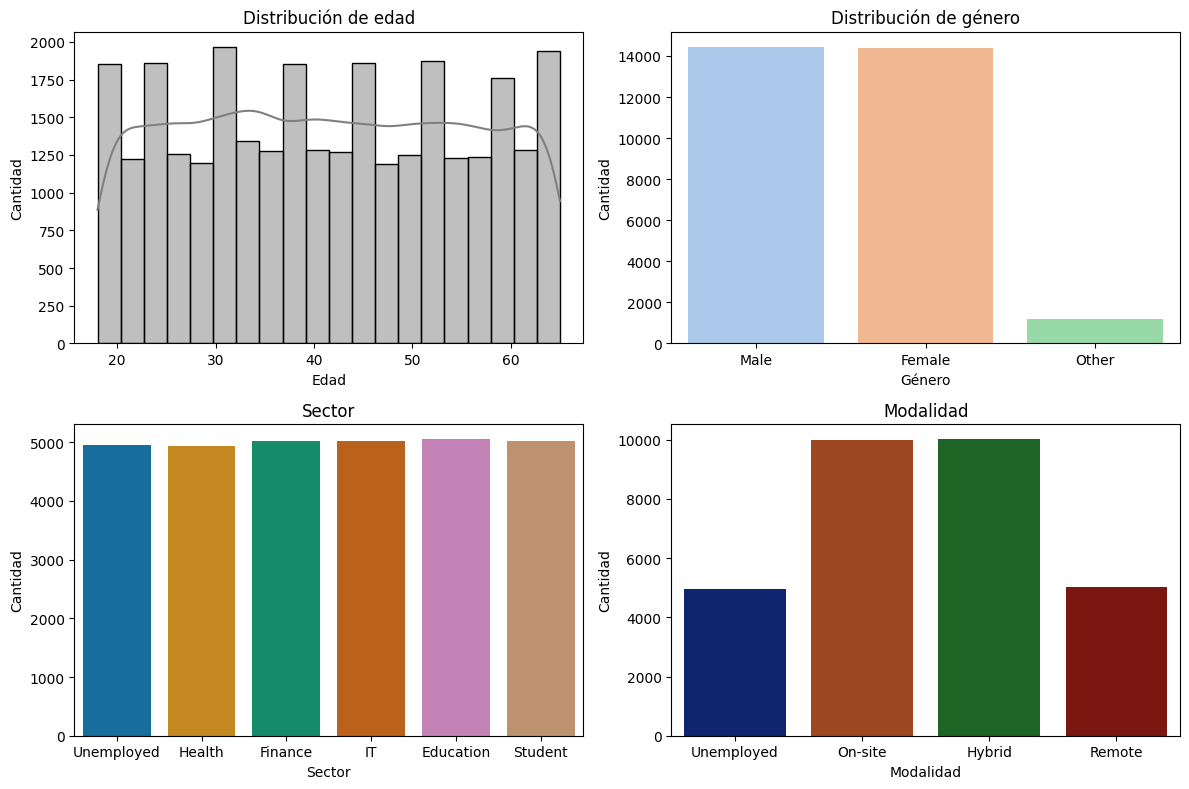

In [27]:
plt.figure(figsize=(12,8))

# edad
plt.subplot(2, 2, 1)
sns.histplot(df_modificado['age'], bins=20, kde=True, color='grey')
plt.title('Distribución de edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')

# Género
plt.subplot(2, 2, 2)
sns.countplot(x='gender', hue='gender', data=df_modificado, palette='pastel', legend=False)
plt.title('Distribución de género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.tight_layout()


#Tipo de trabajo
plt.subplot(2, 2, 3)
sns.countplot(x='job_type', hue='job_type', data=df_modificado, palette='colorblind', legend=False)
plt.title('Sector')
plt.xlabel('Sector')
plt.ylabel('Cantidad')
plt.tight_layout()

#Modalidad
plt.subplot(2, 2, 4)
sns.countplot(x='work_mode', hue='work_mode', data=df_modificado, palette='dark', legend=False)
plt.title('Modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()



En los gráficos anteriores se observa la distribución de edad y género de los participantes del estudio.
La variable edad presenta una distribución relativamente uniforme entre los 18 y los 65 años, con una ligera concentración en los rangos de adultos jóvenes (25 a 40 años), lo que sugiere una muestra predominantemente activa laboralmente.

En cuanto al género, la muestra se encuentra equilibrada entre personas que se identifican como masculino y femenino, mientras que el grupo "Other" representa un porcentaje menor.
Esta distribución equilibrada garantiza diversidad en los datos y permitirá analizar los hábitos digitales y la productividad sin un sesgo fuerte por género o edad.

En relación al sector laboral, predominan los ámbitos de educación, tecnología y finanzas, seguidos por salud y estudiantes. Sin embargo, en la muestra de datos hay poca variabilidad entre los diferentes campos de estudio

Finalmente, en la modalidad de trabajo, los grupos híbrido y presencial son los más frecuentes, mientras que las modalidades remotas y personas desempleadas representan proporciones menores.

###Variables del bienestar personal

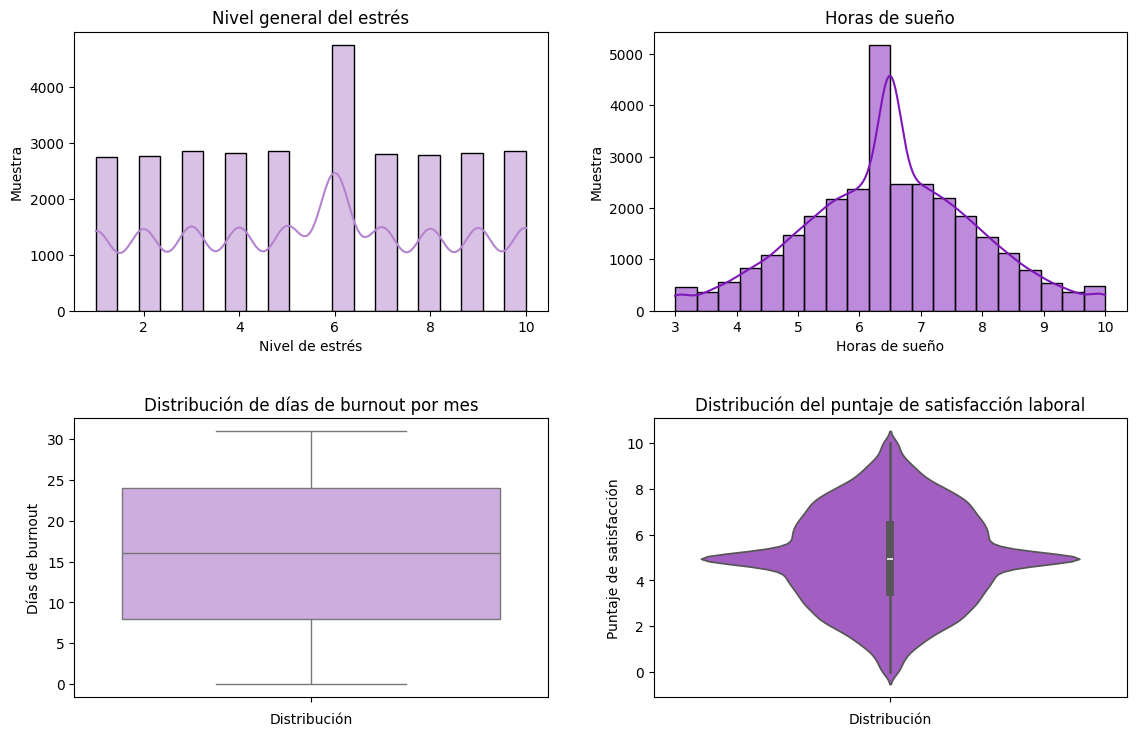

In [28]:
plt.figure(figsize=(12,8))

# Nivel general del estrés
plt.subplot(2, 2, 1)
sns.histplot(df_modificado['stress_level'], bins=20, kde=True, color='#B484CF')
plt.title('Nivel general del estrés')
plt.xlabel('Nivel de estrés')
plt.ylabel('Muestra')

# Horas de sueño
plt.subplot(2, 2, 2)
sns.histplot(df_modificado['sleep_hours'], bins=20, kde=True, color='#7E17BA')
plt.title('Horas de sueño')
plt.xlabel('Horas de sueño')
plt.ylabel('Muestra')

# Días de burnout

plt.subplot(2, 2, 3)
sns.boxplot(
    y='days_feeling_burnout_per_month',
    data=df_modificado,
    color='#CFA4E8'
)
plt.title('Distribución de días de burnout por mes')
plt.ylabel('Días de burnout')
plt.xlabel('Distribución')

# Grado de satisfacción laboral
plt.subplot(2, 2, 4)
sns.violinplot(
    y='job_satisfaction_score',
    data=df_modificado,
    color='#A94DD2',
    inner='box'
)

plt.title('Distribución del puntaje de satisfacción laboral')
plt.ylabel('Puntaje de satisfacción')
plt.xlabel('Distribución')

plt.tight_layout(pad=3.0)
plt.show()


La distribución del **nivel de estrés** muestra una tendencia equilibrada, sin concentraciones extremas, mientras que las **horas de sueño** presentan un patrón normal alrededor de las **6 a 7 horas**, considerado un rango saludable pero bajo.


En cuanto al **burnout**, el boxplot evidencia una alta variabilidad, indicando que una parte de la muestra experimenta episodios de agotamiento frecuentes.


Finalmente, la **satisfacción laboral** muestra una distribución centrada en valores medios, lo que sugiere que la mayoría de los participantes se encuentra moderadamente conforme con su entorno laboral.


###Habitos digitales


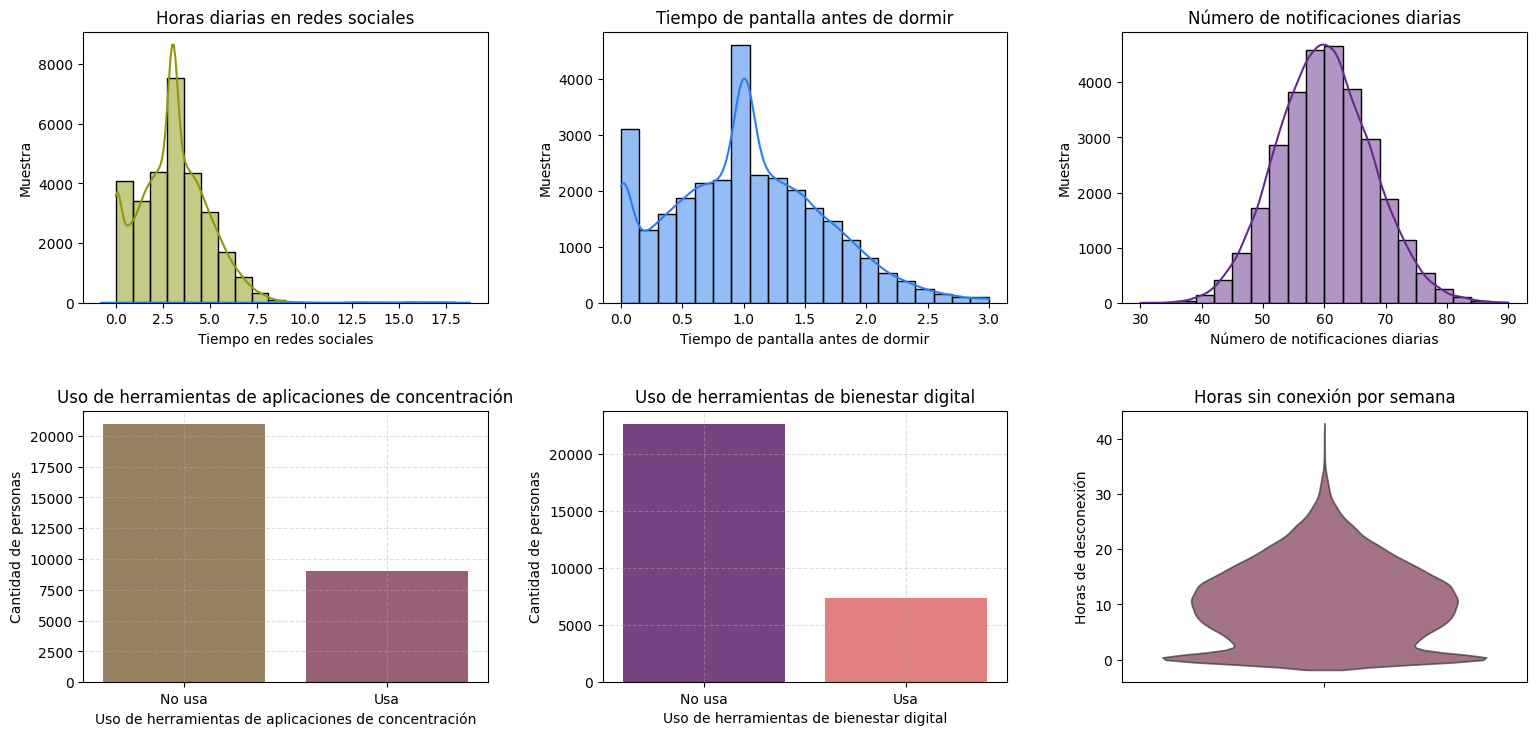

In [29]:
plt.figure(figsize=(16,8))

# uso diario de redes sociales.
plt.subplot(2, 3, 1)
sns.histplot(
    data=df_modificado,
    x='daily_social_media_time',
    bins=20,
    color='#8D990B',
    kde=True
)
sns.kdeplot(
    data=df_modificado,
    x='daily_social_media_time',
    color='#2B7DF0',
    lw=2
)
plt.title('Horas diarias en redes sociales')
plt.xlabel('Tiempo en redes sociales')
plt.ylabel('Muestra')


# Tiempo de pantalla antes de dormir
plt.subplot(2, 3, 2)
sns.histplot(
    data=df_modificado,
    x='screen_time_before_sleep',
    bins=20,
    color='#2B7DF0',
    kde=True
)
plt.title('Tiempo de pantalla antes de dormir')
plt.xlabel('Tiempo de pantalla antes de dormir')
plt.ylabel('Muestra')


# Número de notificaciones diarias
plt.subplot(2, 3, 3)
sns.histplot(
    data=df_modificado,
    x='number_of_notifications',
    bins=20,
    color='#642C8A',
    kde=True
)
plt.title('Número de notificaciones diarias')
plt.xlabel('Número de notificaciones diarias')
plt.ylabel('Muestra')


# Uso de apps de concentración

plt.subplot(2, 3, 4)
df_modificado['uses_focus_apps'] = df_modificado['uses_focus_apps'].replace({True: 'Usa', False: 'No usa'})

sns.countplot(
    data=df_modificado,
    hue='uses_focus_apps',
    x='uses_focus_apps',
    palette=['#8A642C', '#8A2C52'],
    alpha=0.8
)

plt.title('Uso de herramientas de aplicaciones de concentración')
plt.xlabel('Uso de herramientas de aplicaciones de concentración')
plt.ylabel('Cantidad de personas')
plt.grid(True, linestyle='--', alpha=0.4)


# Uso de herramientas de bienestar digital
plt.subplot(2, 3, 5)
df_modificado['has_digital_wellbeing_enabled'] = df_modificado['has_digital_wellbeing_enabled'].replace({True: 'Usa', False: 'No usa'})

sns.countplot(
    data=df_modificado,
    hue='has_digital_wellbeing_enabled',
    x='has_digital_wellbeing_enabled',
    palette='magma',
    alpha=0.9
)

plt.title('Uso de herramientas de bienestar digital')
plt.xlabel('Uso de herramientas de bienestar digital')
plt.ylabel('Cantidad de personas')
plt.grid(True, linestyle='--', alpha=0.4)



#Horas de desconexión
plt.subplot(2, 3, 6)
sns.violinplot(
    data=df_modificado,
    y='weekly_offline_hours',
    color='#8A2C52',
    inner=None,
    alpha=0.7
)

plt.title('Horas sin conexión por semana')
plt.ylabel('Horas de desconexión')

plt.tight_layout(pad=3)
plt.show()






**Uso diario de redes sociales** y **tiempo frente a pantallas antes de dormir** muestran distribuciones sesgadas a la derecha, con mayor concentración de usuarios en niveles bajos a moderados.  

**Número de notificaciones diarias** sigue una distribución aproximadamente normal, centrada en torno a las 60 notificaciones.  

**Uso de aplicaciones de concentración** y **herramientas de bienestar digital** presentan mayor proporción de usuarios que no utilizan estas herramientas.  

**Horas sin conexión por semana**, representadas con un gráfico de violín, muestran una distribución densa en valores intermedios, aunque con gran variabilidad entre usuarios.

Este análisis sirve como punto de partida para comprender patrones de comportamiento y preparar el terreno para exploraciones bivariadas más profundas.

##Gráficos bivariados

Luego de establecer las hipótesis sobre los factores que podrían influir en la productividad, se realiza un análisis bivariado para observar cómo **las variables de bienestar, hábitos digitales y características laborales** se relacionan entre sí.  

Este apartado busca contrastar visualmente las ideas planteadas, explorando si los patrones del dataset respaldan o contradicen las expectativas iniciales.  

En particular, se analizarán relaciones como:  
- El vínculo entre el **tiempo en redes sociales** y la **productividad real**, para determinar si un mayor uso digital se asocia con menor rendimiento.  
- La relación entre el **estrés y las horas de sueño**, evaluando si el descanso adecuado reduce el nivel de estrés percibido.  
- La conexión entre el **uso de herramientas digitales de enfoque** y la **productividad**, identificando si estas estrategias efectivamente mejoran el desempeño.  
- Las diferencias en **satisfacción laboral** según el tipo de trabajo o sector, lo que podría reflejar distintos entornos o niveles de presión.  

A través de estos gráficos bivariados se busca **identificar patrones, correlaciones o dependencias relevantes**, con el fin de reconocer qué variables muestran un mayor peso sobre la productividad y podrían ser utilizadas posteriormente en la construcción del modelo predictivo.


###Relacion entre los hábitos digitales y productividad

Si pasar más tiempo en redes sociales y a mayor número de horas en la pantalla antes de dormir reduce la productividad mientras que el uso de focus apps lo mejora.

/tmp/ipython-input-2650359689.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2650359689.py:49: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(


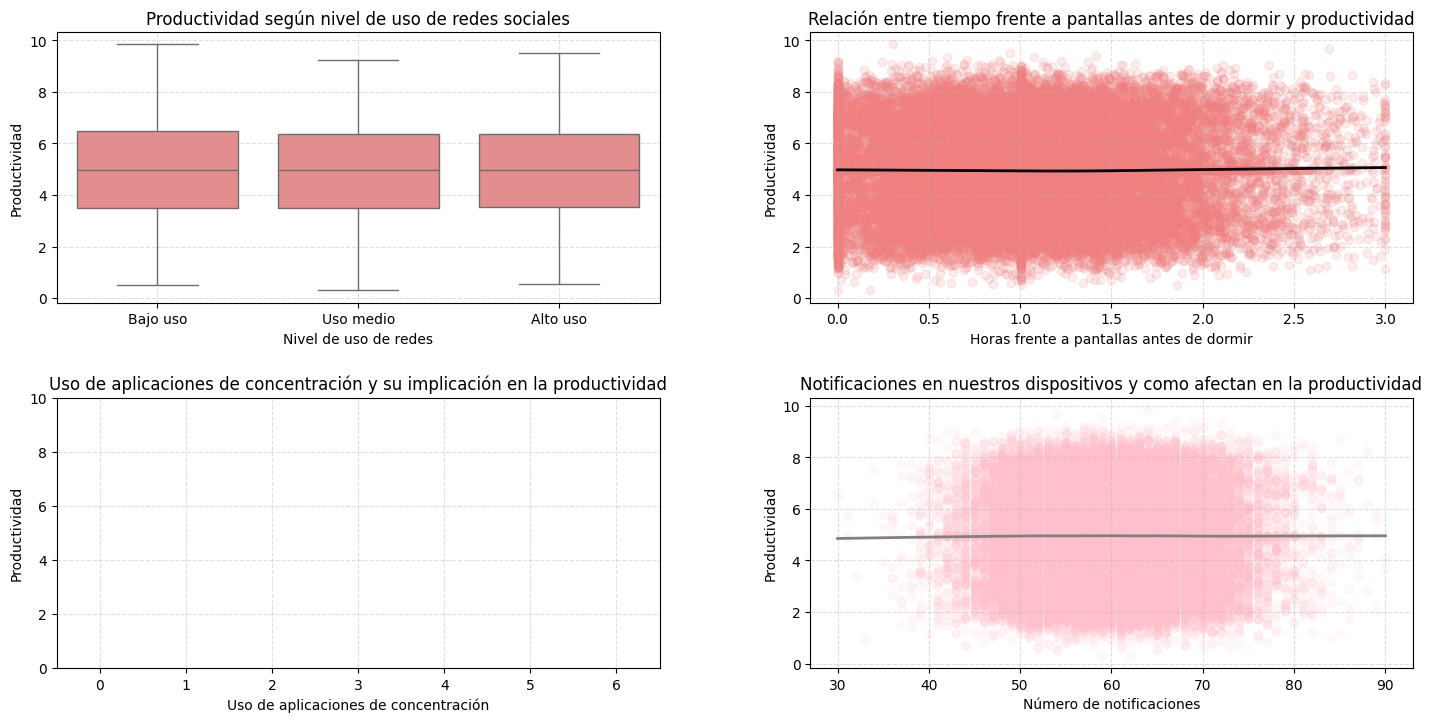

In [14]:
plt.figure(figsize=(15, 8))

#Productividad según nivel de uso de redes sociales
def clasificar_uso(horas):
    if horas < 1.5:
        return 'Bajo uso'
    elif horas <= 3.5:
        return 'Uso medio'
    else:
        return 'Alto uso'


df_modificado['social_media_category'] = df_modificado['daily_social_media_time'].apply(clasificar_uso)

plt.subplot(2, 2, 1)
sns.boxplot(
    x='social_media_category',
    y='actual_productivity_score',
    data=df_modificado,
    color='lightcoral',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)
plt.title('Productividad según nivel de uso de redes sociales')
plt.xlabel('Nivel de uso de redes')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)


#Relación entre tiempo frente a pantallas antes de dormir y productividad
plt.subplot(2, 2, 2)
sns.regplot(
    data=df_modificado,
    x='screen_time_before_sleep',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.15, 'color': 'lightcoral'},
    line_kws={'color': 'black', 'lw': 2},
    lowess=True
)
plt.title('Relación entre tiempo frente a pantallas antes de dormir y productividad')
plt.xlabel('Horas frente a pantallas antes de dormir')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)


#Uso de aplicaciones de concentración y su implicación en la productividad
df_modificado['uses_focus_apps'] = df_modificado['uses_focus_apps'].map({True: 'Usa', False: 'No usa'})

plt.subplot(2, 2, 3)
sns.barplot(
    x='uses_focus_apps',
    y='actual_productivity_score',
    data=df_modificado,
    palette=['lightcoral', 'pink'],
    errorbar=None
)
plt.title('Uso de aplicaciones de concentración y su implicación en la productividad')
plt.xlabel('Uso de aplicaciones de concentración')
plt.ylabel('Productividad')
plt.ylim(0, 10)
plt.grid(True, linestyle='--', alpha=0.4)


#Notificaciones en nuestros dispositivos y como afectan en la productividad
plt.subplot(2, 2, 4)
sns.regplot(
    data=df_modificado,
    x='number_of_notifications',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.1, 'color': 'pink'},
    line_kws={'color': 'grey', 'lw': 2},
    lowess=True
)
plt.title('Notificaciones en nuestros dispositivos y como afectan en la productividad')
plt.xlabel('Número de notificaciones')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)


plt.tight_layout(pad=3.5)
plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()

Los gráficos muestran que los hábitos digitales parecen tener un impacto moderado en la productividad real.
Quienes usan menos las redes sociales presentan, en promedio, niveles ligeramente más altos de productividad, aunque las diferencias no son marcadas.

El tiempo frente a pantallas antes de dormir muestra una débil relación negativa con la productividad, lo que sugiere que una mayor exposición nocturna podría afectar el rendimiento.

Asimismo, se observa que quienes utilizan aplicaciones de concentración obtienen valores de productividad algo superiores, lo que indica un posible efecto positivo del uso de herramientas de enfoque.

Finalmente, el número de notificaciones recibidas mantiene una leve relación inversa con la productividad, apoyando la idea de que la distracción digital puede tener un efecto, aunque reducido, sobre el desempeño diario.

###Relación entre el bienestar personal y productividad

/tmp/ipython-input-1977355242.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


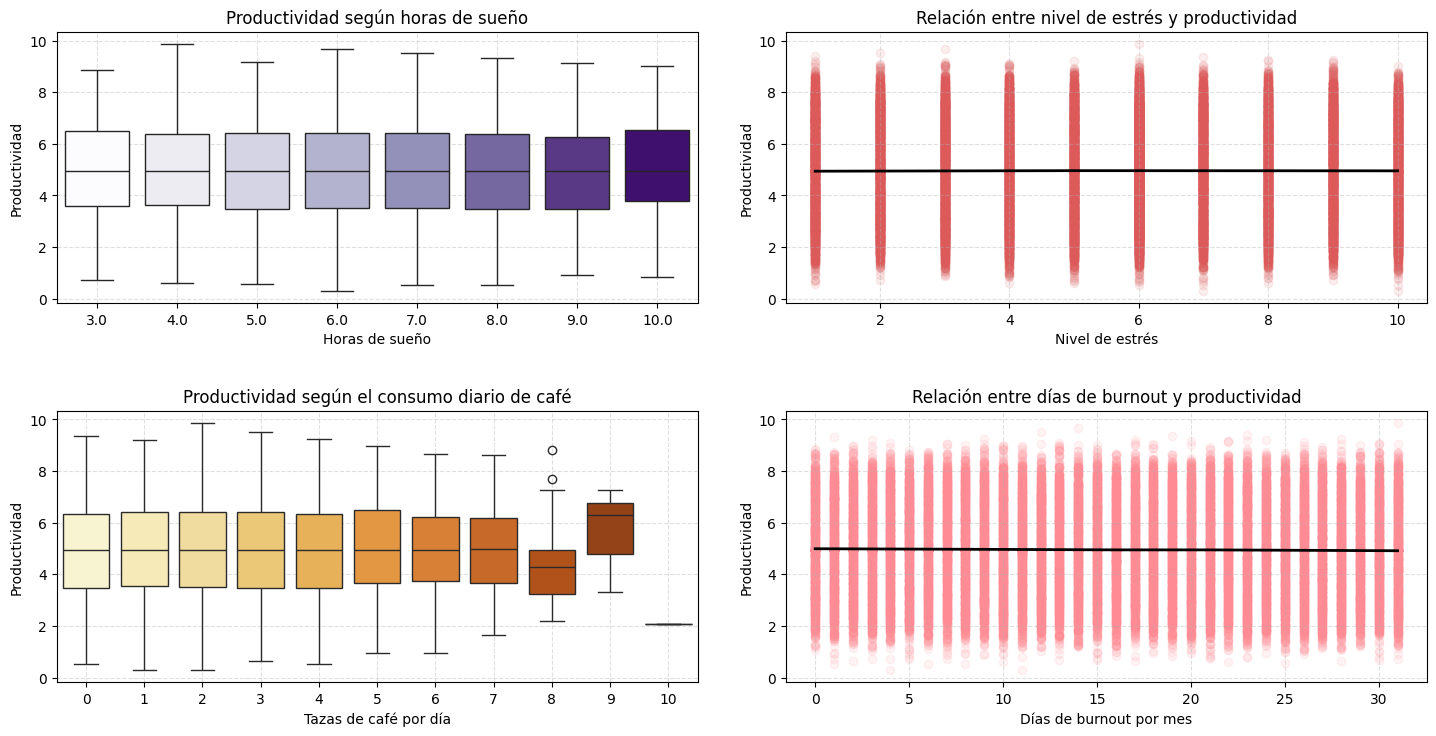

In [15]:
plt.figure(figsize=(15, 8))

# Productividad según horas de sueño
plt.subplot(2, 2, 1)
df_modificado['sleep_hours_rounded'] = df_modificado['sleep_hours'].round()

sns.boxplot(
    data=df_modificado,
    x='sleep_hours_rounded',
    y='actual_productivity_score',
    palette='Purples',
    hue='sleep_hours_rounded'
)
plt.title('Productividad según horas de sueño')
plt.xlabel('Horas de sueño')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend([], [], frameon=False)

# Nivel de estrés vs Productividad
plt.subplot(2, 2, 2)
sns.regplot(
    data=df_modificado,
    x='stress_level',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.1, 'color': '#DD5A5A'},
    line_kws={'color': 'black', 'lw': 2},
    lowess=True
)
plt.title('Relación entre nivel de estrés y productividad')
plt.xlabel('Nivel de estrés')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

# Consumo de café vs Productividad
plt.subplot(2, 2, 3)
df_modificado['coffee_consumption_per_day'] = df_modificado['coffee_consumption_per_day'].round()

sns.boxplot(
    data=df_modificado,
    x='coffee_consumption_per_day',
    y='actual_productivity_score',
    palette='YlOrBr'
)
plt.title('Productividad según el consumo diario de café')
plt.xlabel('Tazas de café por día')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

# Días de burnout vs Productividad
plt.subplot(2, 2, 4)
sns.regplot(
    data=df_modificado,
    x='days_feeling_burnout_per_month',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.1, 'color': '#FF8C94'},
    line_kws={'color': 'black', 'lw': 2},
    lowess=True
)
plt.title('Relación entre días de burnout y productividad')
plt.xlabel('Días de burnout por mes')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(pad=3.0)
plt.show()


Los resultados muestran cómo diversos factores personales afectan el rendimiento. Se observa que quienes duermen entre 7 y 8 horas tienden a alcanzar mayores niveles de productividad. Del mismo modo, niveles altos de estrés y más días mensuales con burnout están asociados con un menor desempeño. En cuanto al consumo de café, no se evidencia una tendencia clara, aunque el exceso podría estar vinculado a menor productividad. Estos hallazgos refuerzan la importancia de mantener hábitos saludables para optimizar el rendimiento diario.

###Relación entre los factores laborales y productividad


/tmp/ipython-input-1603196888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1603196888.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


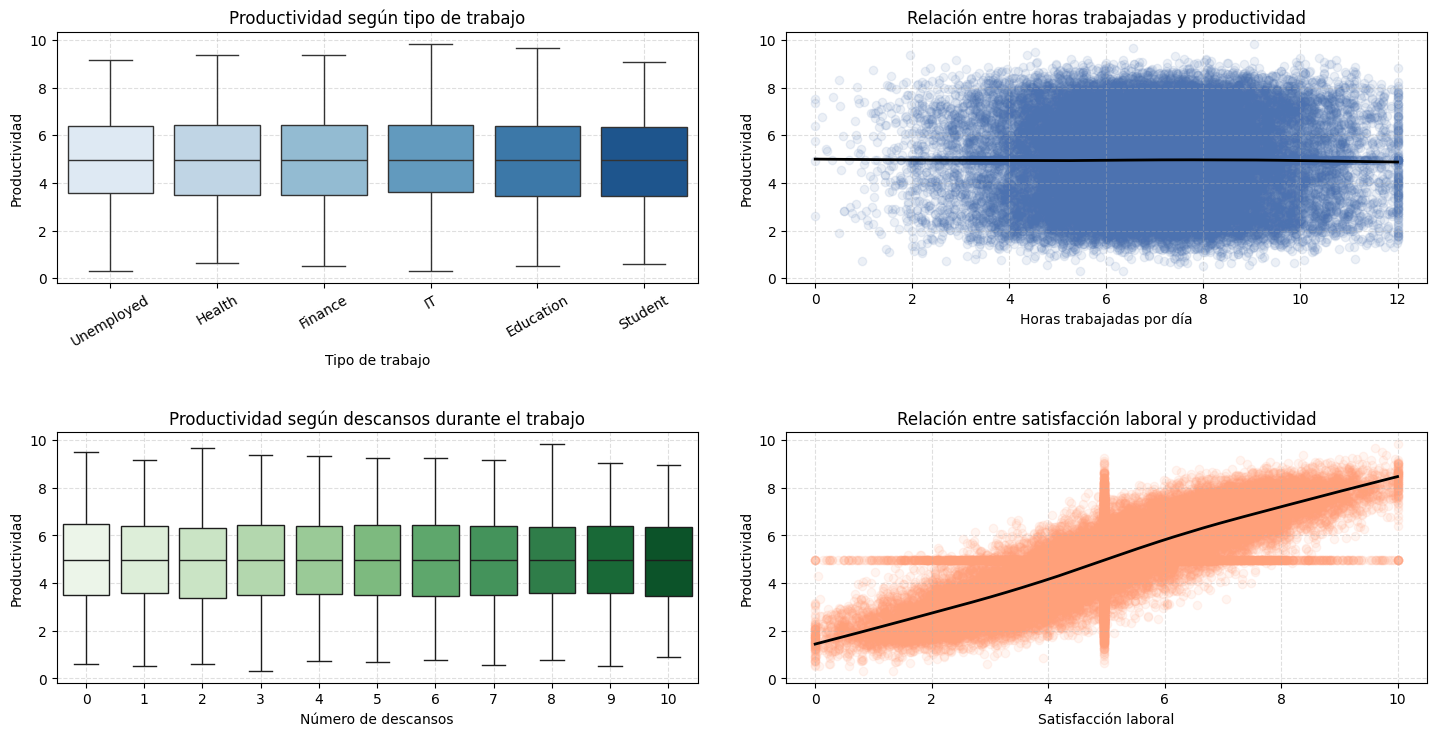

In [16]:
plt.figure(figsize=(15, 8))

# Tipo de trabajo vs Productividad
plt.subplot(2, 2, 1)
sns.boxplot(
    data=df_modificado,
    x='job_type',
    y='actual_productivity_score',
    palette='Blues'
)
plt.title('Productividad según tipo de trabajo')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Productividad')
plt.xticks(rotation=30)
plt.grid(True, linestyle='--', alpha=0.4)

# Horas trabajadas por día vs Productividad
plt.subplot(2, 2, 2)
sns.regplot(
    data=df_modificado,
    x='work_hours_per_day',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.1, 'color': '#4C72B0'},
    line_kws={'color': 'black', 'lw': 2},
    lowess=True
)
plt.title('Relación entre horas trabajadas y productividad')
plt.xlabel('Horas trabajadas por día')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

# Descansos durante el trabajo vs Productividad
plt.subplot(2, 2, 3)
sns.boxplot(
    data=df_modificado,
    x='breaks_during_work',
    y='actual_productivity_score',
    palette='Greens'
)
plt.title('Productividad según descansos durante el trabajo')
plt.xlabel('Número de descansos')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

# Satisfacción laboral vs Productividad
plt.subplot(2, 2, 4)
sns.regplot(
    data=df_modificado,
    x='job_satisfaction_score',
    y='actual_productivity_score',
    scatter_kws={'alpha': 0.1, 'color': '#FFA07A'},
    line_kws={'color': 'black', 'lw': 2},
    lowess=True
)
plt.title('Relación entre satisfacción laboral y productividad')
plt.xlabel('Satisfacción laboral')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(pad=3.0)
plt.show()


El **tipo de trabajo** muestra diferencias visibles entre categorías, lo que sugiere que algunas tareas pueden favorecer un mayor rendimiento.  
La relación entre **horas trabajadas** y productividad no siempre es lineal: trabajar más no garantiza producir más, ya que el exceso de horas puede generar fatiga.  
En cuanto a los **descansos durante la jornada**, se observa que las pausas moderadas tienden a asociarse con niveles estables o superiores de productividad, indicando que los descansos estratégicos podrían ser beneficiosos.  
Finalmente, la **satisfacción laboral** presenta una correlación positiva con la productividad, respaldando la idea de que un entorno laboral favorable mejora el desempeño general.  



##Gráficos multivariados

Luego de explorar las relaciones bivariadas, este apartado aborda un **análisis multivariado**, con el objetivo de comprender cómo **varios factores interactúan simultáneamente** en la productividad.  
No se busca solo identificar asociaciones simples, sino observar combinaciones de variables que puedan potenciar o contrarrestar sus efectos.

En esta etapa se analizan patrones conjuntos entre **bienestar personal, hábitos digitales y condiciones laborales**, para detectar dinámicas más complejas dentro del comportamiento productivo.  

Algunos focos de análisis incluyen:

- Cómo el **estrés y las horas de sueño** actúan conjuntamente sobre la productividad, evaluando si el descanso adecuado puede amortiguar el impacto del estrés.  
- La relación entre **satisfacción laboral, tipo de trabajo y desempeño**, identificando si ciertos entornos fomentan un mejor rendimiento.  
- El equilibrio entre **horas trabajadas y descansos**, buscando combinaciones que optimicen la productividad sin aumentar la fatiga.  
- Cómo el **uso digital** (tiempo en redes o herramientas de enfoque) interactúa con factores de bienestar emocional.

Estos gráficos multivariados permiten **visualizar interacciones y efectos combinados**, aportando una visión más integral sobre los elementos que influyen en la productividad y orientando los próximos pasos del análisis predictivo.

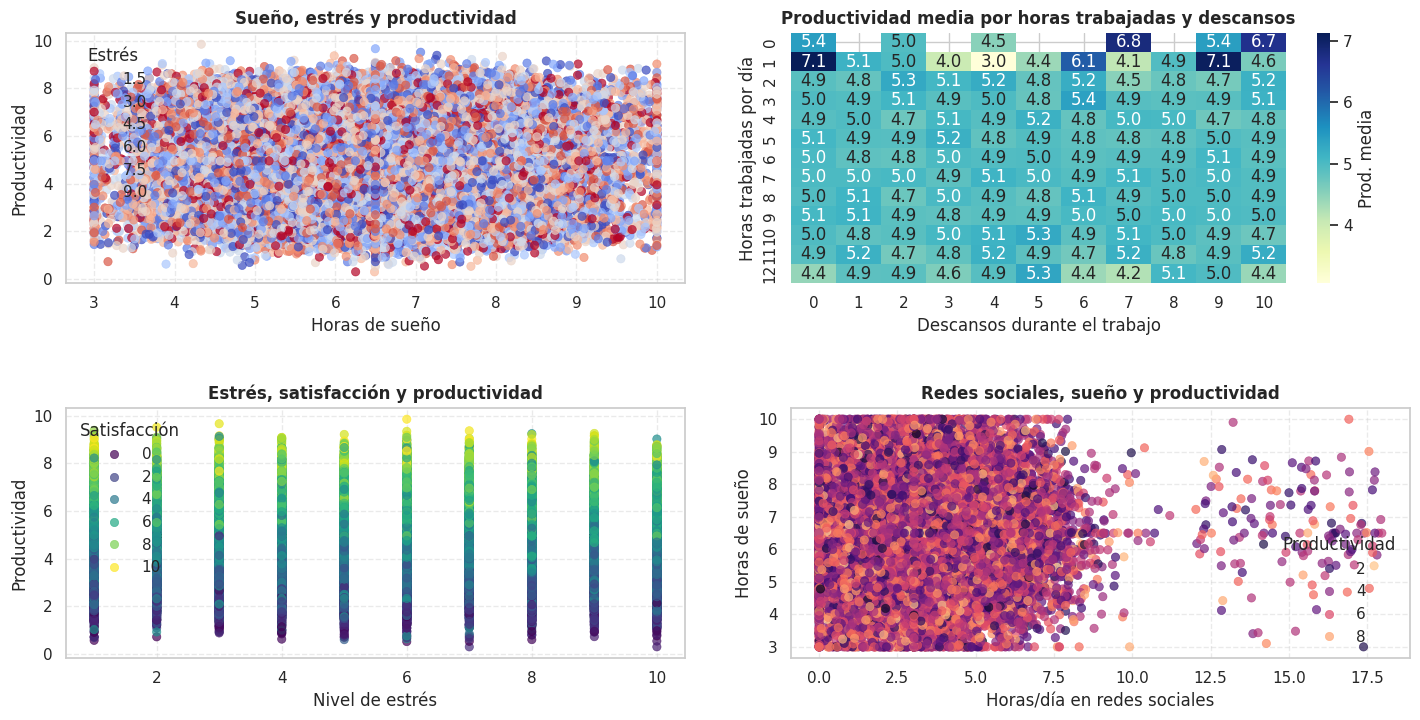

In [31]:

plt.figure(figsize=(15, 8))
sns.set(style="whitegrid")
plt.rcParams['axes.titleweight'] = 'bold'


plt.subplot(2, 2, 1)
tmp1 = df_modificado[['sleep_hours', 'stress_level', 'actual_productivity_score']].dropna()
sns.scatterplot(
    data=tmp1,
    x='sleep_hours',
    y='actual_productivity_score',
    hue='stress_level',
    palette='coolwarm',
    alpha=0.7,
    edgecolor=None
)

plt.title('Sueño, estrés y productividad')
plt.xlabel('Horas de sueño')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Estrés', loc='best', frameon=False)


plt.subplot(2, 2, 2)
tmp2 = df_modificado[['work_hours_per_day', 'breaks_during_work', 'actual_productivity_score']].dropna().copy()

tmp2['work_hours_per_day'] = tmp2['work_hours_per_day'].round(0).astype(int)
tmp2['breaks_during_work'] = tmp2['breaks_during_work'].round(0).astype(int)

pivot = tmp2.pivot_table(
    values='actual_productivity_score',
    index='work_hours_per_day',
    columns='breaks_during_work',
    aggfunc='mean'
).sort_index(axis=0).sort_index(axis=1)

ax = sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': 'Prod. media'}
)
plt.title('Productividad media por horas trabajadas y descansos')
plt.xlabel('Descansos durante el trabajo')
plt.ylabel('Horas trabajadas por día')


plt.subplot(2, 2, 3)
tmp3 = df_modificado[['stress_level', 'job_satisfaction_score', 'actual_productivity_score']].dropna()
sns.scatterplot(
    data=tmp3,
    x='stress_level',
    y='actual_productivity_score',
    hue='job_satisfaction_score',
    palette='viridis',
    alpha=0.7,
    edgecolor=None
)
plt.title('Estrés, satisfacción y productividad')
plt.xlabel('Nivel de estrés')
plt.ylabel('Productividad')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Satisfacción', loc='best', frameon=False)


plt.subplot(2, 2, 4)
tmp4 = df_modificado[['daily_social_media_time', 'sleep_hours', 'actual_productivity_score']].dropna()

sns.scatterplot(
    data=tmp4,
    x='daily_social_media_time',
    y='sleep_hours',
    hue='actual_productivity_score',
    palette='magma',
    alpha=0.7,
    edgecolor=None
)
plt.title('Redes sociales, sueño y productividad')
plt.xlabel('Horas/día en redes sociales')
plt.ylabel('Horas de sueño')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Productividad', loc='best', frameon=False)

plt.tight_layout(pad=3.0)
plt.show()


Los gráficos anteriores permiten observar **cómo interactúan varios factores simultáneamente** en la productividad real de los participantes.

- **Sueño, estrés y productividad:** se aprecia una ligera tendencia a que mayores horas de sueño se asocian con niveles de productividad más estables, especialmente en valores bajos de estrés. A medida que el estrés aumenta, la productividad se vuelve más dispersa, lo que sugiere que el descanso puede atenuar su impacto negativo.

- **Horas trabajadas, descansos y productividad:** el mapa de calor revela zonas con productividad media más alta en torno a jornadas moderadas (6–8 horas) y descansos intermedios. Trabajar más horas no necesariamente mejora el desempeño, y la ausencia de pausas podría afectar la eficiencia.

- **Estrés, satisfacción y productividad:** se observa que los niveles más altos de satisfacción laboral se relacionan con mayores valores de productividad, incluso en condiciones de estrés elevado, lo que refuerza el rol positivo del bienestar emocional en el rendimiento.

- **Redes sociales, sueño y productividad:** el uso intensivo de redes se asocia con menos horas de sueño y una productividad ligeramente menor, indicando que los hábitos digitales pueden interferir en el descanso y, en consecuencia, en el desempeño general.


##Conclusión final del AEV

El análisis realizado permitió comprender de manera más profunda cómo distintos factores personales, digitales y laborales interactúan e influyen en la **productividad real**.  
Los resultados muestran que las variables con **mayor peso** en el rendimiento son aquellas relacionadas con el **bienestar emocional y la satisfacción laboral**. En particular, los participantes con niveles altos de satisfacción y bajos niveles de estrés presentan una productividad claramente superior, incluso frente a condiciones laborales exigentes.  

Asimismo, las **horas de sueño** demostraron tener un efecto estabilizador importante: dormir lo suficiente ayuda a mantener la concentración y reduce el impacto negativo del estrés. En cambio, el **uso intensivo de redes sociales** y el **exceso de horas de trabajo sin descansos adecuados** se asocian con una disminución en la eficiencia, evidenciando la influencia negativa de los hábitos digitales y del desequilibrio entre esfuerzo y recuperación.  

En conjunto, estos hallazgos confirman que la productividad no depende de un único aspecto, sino del **equilibrio integral entre bienestar personal, hábitos saludables y entorno laboral**.  
Esta etapa exploratoria sienta una base sólida para el siguiente paso del proyecto: el desarrollo de un **modelo predictivo** que permita cuantificar con mayor precisión el peso de cada factor sobre la productividad individual, aportando evidencia útil para el diseño de estrategias de mejora en el ámbito laboral y personal.
